In [1]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from load_data import get_dataset
from pipeline_tree_model import get_preprocessor

In [2]:
X_train, X_test, y_train, y_test = get_dataset()

In [3]:
preprocessor = get_preprocessor()

In [4]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

The fundamental issue is that this dataset has three distinct subpopulations:
Low cost non-smokers - charges typically 1,000 to 15,000
Medium cost smokers with normal BMI - charges typically 15,000 to 30,000
High cost smokers with high BMI - charges typically 30,000 to 60,000
These three groups do not form a single continuous distribution. They are discrete clusters with gaps between them. When you train any model on this data, the predictions naturally separate into those same clusters, and the residual plot will always show a non-random structure because the underlying data is non-random in its distribution.

In [5]:
params_grid = {
    "model__n_estimators": [200, 300],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True],
    "model__max_depth": [None, 10, 15],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 10],
    "model__criterion": ["absolute_error"]
}

In [6]:
grid = GridSearchCV(pipe, param_grid=params_grid, cv=3, scoring="neg_mean_absolute_error", verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 3 folds for each of 192 candidates, totalling 576 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True], 'model__criterion': ['absolute_error'], 'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 :

In [7]:
y_pred = grid.predict(X_test)

In [8]:
print("Training")
print("R2 Score", r2_score(y_train, grid.predict(X_train)))
print("MAE", mean_absolute_error(y_train, grid.predict(X_train)))
print("MSE", mean_squared_error(y_train, grid.predict(X_train)))
print("RMSE", root_mean_squared_error(y_train, grid.predict(X_train)))
print("\n")
print("Testing")
print("R2 Score", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", root_mean_squared_error(y_test, y_pred))

Training
R2 Score 0.883416591135902
MAE 1633.3287662511136
MSE 16915132.704856016
RMSE 4112.801077715286


Testing
R2 Score 0.8620833234876754
MAE 1977.209309052736
MSE 20810404.50321042
RMSE 4561.842226909039


In [9]:
grid.best_params_

{'model__bootstrap': True,
 'model__criterion': 'absolute_error',
 'model__max_depth': None,
 'model__max_features': 'log2',
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

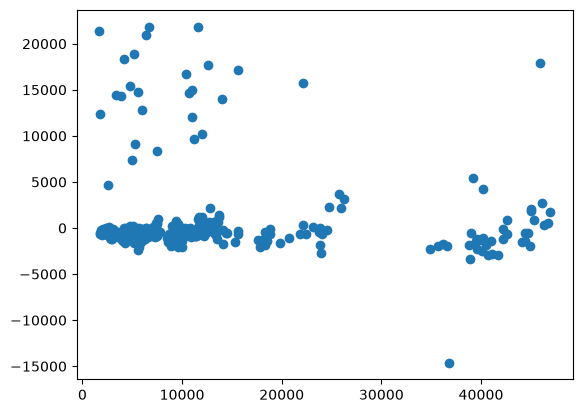

In [10]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.show()